In [1]:
import pandas as pd
import plotnine as p9
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
#Reading .csv files
t06 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2006.csv")
t07 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2007.csv")
t09 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2009.csv")
t10 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2010.csv")
t11 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2011.csv")
t12 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2012.csv")
t13 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2013.csv")
t14 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2014.csv")
t15 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2015.csv")
t16 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2016.csv")
t17 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2017.csv")
t18 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2018.csv")
t19 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2019.csv")
t20 = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\2020.csv")
h_recycle = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\household-recycling-borough.csv")
income = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\income-of-tax-payers.csv")
price = pd.read_csv(r"C:\Users\samur\Desktop\LIS schoolwork\LIS TERM 2\quant1b_group_summative\Quant-1b-p9-main\house-prices.csv",)

In [3]:
#checking the format
t07.head()

,Borough,Own Outright,Buying with mortgage
0,Barking and Dagenham,21.5,34.3
1,Barnet,30.1,36.8
2,Bexley,32.6,45.3
3,Brent,23.9,30.2
4,Bromley,31.6,42.9


In [4]:
#making a list of the all the dataframes to concat them all together
df_list= []
df_list.append(t06)
df_list.append(t07)
df_list.append(t09)
df_list.append(t10)
df_list.append(t11)
df_list.append(t12)
df_list.append(t13)
df_list.append(t14)
df_list.append(t15)
df_list.append(t16)
df_list.append(t17)
df_list.append(t18)
df_list.append(t19)
df_list.append(t20)

#add a year column to tenure df's 
count = 0
for i in df_list:
    count = count + 1
    if count == 1:
        i["Year"] = 2006
    elif count ==2:
        i["Year"] = 2007
    else:
        i["Year"] = 2006 + count


for i in df_list:
    #renaming "Borough" column to "Area"
    i.rename(columns={"Borough":"Area"}, inplace=True)

    #getting rid of "inner london", "outer london" and "london" rows
    i.drop([32,33,34], axis=0, inplace=True)   

#concatanating tenure dataframes
tenure = pd.concat(df_list, ignore_index=True)

tenure.head()


,Area,Own Outright,Buying with mortgage,Year
0,Barking and Dagenham,21.6,32.4,2006
1,Barnet,27.7,35.0,2006
2,Bexley,28.5,47.2,2006
3,Brent,21.3,32.3,2006
4,Bromley,34.0,40.6,2006


In [5]:
#checking h_recycle
h_recycle.head()

,New Code,Code,Area,"1998/991,2","1999/001,2","2000/011,2","2001/021,2",2002/031,2003/041,2004/05,...,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E09000001,00AA,City of London,0.0,0,0.0,0.0,1.0,8.0,14.0,...,34.0,31.0,29.0,29.0,30.0,29.0,30.0,32.0,30.0,27.0
2,E09000002,00AB,Barking and Dagenham,3.0,3,4.0,3.0,3.0,5.0,14.0,...,23.0,19.0,25.0,25.0,24.0,25.0,27.0,31.0,33.0,33.0
3,E09000003,00AC,Barnet,9.0,8,8.0,8.0,13.0,16.0,20.0,...,38.0,37.0,37.0,37.0,35.0,32.0,29.0,30.0,27.0,29.0
4,E09000004,00AD,Bexley,20.0,18,17.0,20.0,23.0,21.0,30.0,...,54.0,52.0,53.0,52.0,54.0,54.0,50.0,43.0,44.0,46.0


In [6]:
#RUN THIS CELL TO ORGANIZE HOUSEHOLD RECYCLING DATAFRAME

#dropping blanks
hr=h_recycle.dropna().reset_index(drop=True)

#dropping columns in hr df (Area code, Code, years < 2006 and > 2020)
cols_hr = [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 13, 26, 27, 28]
hr.drop(hr.columns[cols_hr], axis=1, inplace=True)

#dropping rows in hr df (NaN's and locations that we are not interested in)
rows_hr = [0, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
hr.drop(hr.index[rows_hr], inplace=True)

#changing the column names for better merge
hr.columns = ["Area", "2006", "2007", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020"]

#making a column for years and a new column for RR/HH (recycling rate per household)
hr = hr.melt(
    id_vars=["Area"]
    ,var_name="Year"
    ,value_name="RR/HH"
)
hr = hr[["Year", "Area", "RR/HH"]]

#making years integers
hr["Year"] = hr.Year.astype("int")

#resetting index
hr = hr.reset_index(drop=True)

hr.head()

,Year,Area,RR/HH
0,2006,Barking and Dagenham,21.0
1,2006,Barnet,29.0
2,2006,Bexley,40.0
3,2006,Brent,22.0
4,2006,Bromley,32.0


In [7]:
#checking format for income df
income

,Year,Area,Number of Individuals,Mean £,Median £
0,2006.0,City of London,"10,000","99,200","49,000"
1,2006.0,Barking and Dagenham,"77,000","20,600","17,600"
2,2006.0,Barnet,"173,000","36,700","20,400"
3,2006.0,Bexley,"123,000","24,600","19,600"
4,2006.0,Brent,"144,000","24,600","18,200"
...,...,...,...,...,...
708,2020.0,Wales,"1,420,000","30,400","24,400"
709,2020.0,Scotland,"2,580,000","33,600","26,000"
710,2020.0,Northern Ireland,"783,000","31,100","24,800"
711,2020.0,NaN,NaN,NaN,NaN


In [8]:
#RUN THIS CELL TO ORGANIZE INCOME DATAFRAME

#cleaning rows
income = income.dropna()
income = income.set_index(income["Area"], drop = False)
income = income.drop(["City of London"
                      , "North East"
                      , "North West"
                      , "Yorkshire and The Humber"
                      , "East Midlands"
                      , "West Midlands"
                      , "East of England"
                      , "South East"
                      , "South West"
                      , "England"
                      , "Wales"
                      , "Scotland"
                      , "Northern Ireland"
                      , "United Kingdom"
                      , "London"
                      ]
                      , axis="index")
income = income.reset_index(drop = True)

#making the years integers
income["Year"] = income["Year"].astype("int")

#dropping "Number of individuals" column
income.drop(["Number of Individuals"], axis=1, inplace=True)

#renaming the Mean and Median to get rid of GBP symbol
income.rename(columns={"Mean £":"Mean","Median £":"Median"},inplace=True)

#replacing "-" with " "
income["Area"] = income["Area"].str.replace("-", " ", regex=True)

income.head()

,Year,Area,Mean,Median
0,2006,Barking and Dagenham,"20,600","17,600"
1,2006,Barnet,"36,700","20,400"
2,2006,Bexley,"24,600","19,600"
3,2006,Brent,"24,600","18,200"
4,2006,Bromley,"32,800","23,000"


In [9]:
#checking format for price df
price

,Year,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,Enfield,...,Merton,Newham,Redbridge,Richmond upon Thames,Southwark,Sutton,Tower Hamlets,Waltham Forest,Wandsworth,Westminster
0,Jan-06,"166,874","299,474","188,008","267,130","244,404","365,180","207,375","264,898","227,363",...,"260,921","207,079","228,190","350,594","260,445","210,332","259,211","207,294","326,720","432,051"
1,Feb-06,"167,577","298,187","187,230","265,285","245,892","370,093","210,189","268,798","226,373",...,"263,953","204,552","229,801","352,108","261,327","211,688","255,656","208,381","327,840","446,945"
2,Mar-06,"166,529","298,774","187,445","266,052","247,340","373,727","211,546","267,776","225,595",...,"263,221","202,396","228,546","355,706","262,645","213,466","251,002","208,156","337,932","448,956"
3,Apr-06,"168,790","300,399","189,189","266,283","248,127","379,266","212,008","269,268","227,633",...,"269,496","203,887","229,309","360,564","266,154","213,879","257,017","208,538","343,901","452,515"
4,May-06,"170,686","303,852","189,821","268,553","248,795","385,866","211,271","272,862","229,258",...,"270,888","208,873","230,553","363,390","274,591","214,293","260,893","209,664","351,425","452,497"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,Aug-20,"312,479","558,856","347,933","536,864","441,736","827,652","379,791","518,898","423,474",...,"565,302","390,322","411,614","731,550","584,189","381,460","506,248","464,221","699,768","1,037,669"
164,Sep-20,"309,235","565,007","345,477","563,715","444,664","839,702","382,323","523,227","426,015",...,"566,320","386,132","417,561","731,719","589,931","386,655","520,304","471,569","721,497","999,225"
165,Oct-20,"311,275","562,925","345,406","564,860","445,564","825,440","383,854","523,059","432,225",...,"578,074","391,311","420,048","731,525","595,599","389,397","523,820","481,837","718,177","961,810"
166,Nov-20,"312,061","561,616","346,735","558,799","454,616","807,686","386,933","527,127","429,901",...,"586,643","393,359","429,243","733,238","608,047","394,206","514,838","485,105","710,541","955,109"


In [10]:
#RUN THIS CELL ONCE TO ORGANIZE PRICE DATAFRAME

#setting index as Year column
price = price.set_index("Year", drop=True)

#making the values into the right format
for col in price.columns:
    price[col]=price[col].astype(str).str.replace(",","").astype(float)

#changing the date format in the "Year" column
price.index= pd.to_datetime(price.index, format="%b-%y")

#making a "Year" column
price["Year"] = price.index.year

#resetting the index
price.reset_index(drop=True, inplace=True)

#averaging the values
price = price.groupby("Year").mean()

#resetting the index again
price.reset_index(drop=False, inplace=True)

#rounding the values and formatting them to int
price = price.round(0).astype(int)

#melting the dataset so that we get the "Area" column
price = price.melt(
    id_vars="Year"
    ,var_name="Area"
    ,value_name="Price"
)

#getting rid of "&"
price["Area"] = price["Area"].str.replace("&", "and", regex=True)

#sorting the dataset by the year
price.sort_values(by="Year", ascending=True, inplace=True)

#resetting the index again again
price.reset_index(drop=True,inplace=True)

price.head()

,Year,Area,Price
0,2006,Wandsworth,356755
1,2006,Southwark,280202
2,2006,Brent,273046
3,2006,Barking and Dagenham,172541
4,2006,Croydon,215055


In [11]:
#making the final dataframe, final adjustments and checking integrity
income_tenure = pd.merge(income, tenure)
income_tenure_price = pd.merge(income_tenure, price)
final = pd.merge(hr, income_tenure_price)

#getting rid of commas and spaces
final["Mean"] = final["Mean"].str.replace(",","", regex=True)
final["Median"] = final["Median"].str.replace(",","", regex=True)

#renaming columns for easier use in rec_plot()
final.rename(columns = {"RR/HH":"HHRR", "Own Outright": "Own", "Buying with mortgage": "Mortgage"}, inplace=True)

#changing dtypes of values per column
final["Mean"] = final["Mean"].astype("float").astype("int")
final["Median"] = final["Median"].astype("float").astype("int")
final["HHRR"] = final["HHRR"].astype("float")
final["Own"] = final["Own"].astype("float")
final["Mortgage"] = final["Mortgage"].astype("float")
final["Year"] = final["Year"].astype("int")

#checking integrity
print("We are looking at 14 years of data and we have 32 areas, therefore we should have", 14*32, "rows.")
print("The final dataframe has", len(final),"rows and",len(final.columns),"columns.")
print("In order to check that we have no missing data, we can make the following calculation: 448 rows times 8 columns =", len(final)*len(final.columns),"values.")
print("Using Numpy.count_nonzero, we see that the final dataframe has", np.count_nonzero(final), "values.")
final

We are looking at 14 years of data and we have 32 areas, therefore we should have 448 rows.
The final dataframe has 448 rows and 8 columns.
In order to check that we have no missing data, we can make the following calculation: 448 rows times 8 columns = 3584 values.
Using Numpy.count_nonzero, we see that the final dataframe has 3584 values.


,Year,Area,HHRR,Mean,Median,Own,Mortgage,Price
0,2006,Barking and Dagenham,21.0,20600,17600,21.6,32.4,172541
1,2006,Barnet,29.0,36700,20400,27.7,35.0,309024
2,2006,Bexley,40.0,24600,19600,28.5,47.2,191826
3,2006,Brent,22.0,24600,18200,21.3,32.3,273046
4,2006,Bromley,32.0,32800,23000,34.0,40.6,254004
...,...,...,...,...,...,...,...,...
443,2020,Sutton,46.0,41400,31400,36.8,35.3,382900
444,2020,Tower Hamlets,19.0,52700,34100,10.1,20.1,511605
445,2020,Waltham Forest,32.0,37100,28900,27.1,38.5,465919
446,2020,Wandsworth,24.0,75300,39000,18.0,36.8,700042


In [12]:
#Making a function that returns the OLS, the plot and the residual plot

#making a function for the plot and residual plot
def plot(data, dv, col):
    
    #making a label for the dependent variable
    if dv == "HHRR":
        dv_lab = "Household Recycling Rate"
    elif dv == "Price":
        dv_lab = "House Prices"
    else:
        dv_lab = dv

    #Making variables for the labels
    title = "Corr. between "+dv_lab+" and "
    
    if col == "Mean":
        x_lab = "Mean Income"
        title += x_lab
    
    elif col == "Median":
        x_lab = "Median Income"
        title += x_lab

    elif col == "Year":
        x_lab = col
        title += x_lab

    elif col == "Own":
        x_lab = "Own Outright"
        title += x_lab

    elif col == "Mortgage":
        x_lab = "Buying with mortgage"
        title += x_lab

    elif col == "Price":
        x_lab = "Mean House Price"
        title += x_lab

    elif col == "Area":
        print("Cannot compute Area with this plot")
        
    #Plot
    y = data[dv]
    x = data[col]
    plot = (
        p9.ggplot(data
                  ,p9.aes(x = x
                          ,y = y
                         )
                 )
        +p9.theme_matplotlib()
        +p9.scale_linetype_manual(
            values = {"Correlation line" : "dotted"}
        )
        +p9.geom_point()
        +p9.geom_smooth(
            p9.aes(linetype = '"Correlation line"')
            ,method="lm"
            ,se = False
        )
        +p9.labs(
            x = x_lab
            ,y = dv_lab
            ,title = title
            ,linetype = ""
        )
    )

    #Making Residual plot
    resid_plot=sns.residplot(data, x=x, y=y, color="black");plt.xlabel(x_lab);plt.ylabel(dv_lab);plt.title("Residual Plot:\nCorr. between "+dv_lab+" and "+x_lab);plt.show()
    
    return plot
    return resid_plot

#making a function for the OLS
def rec(data, dv, col, *cols):

    #calling fstring first so we can add to it as we go
    fstring = dv + " ~ " + col

    #making *args work
    count = 0
    for i in cols:
        count += 1
        fstring += " + "+ i

    #Receipt
    model = sm.formula.ols(formula = fstring, data = data)
    model_fitted = model.fit()
    print(model_fitted.summary())

    #Making some prints for easier readability
    if data[col].dtype == int or float:
        print(
            "\nThe correlation coefficient is "+str(data[col].corr(data[dv]))+
            ".\nThe intercept value is "+str(model_fitted.params.iloc[0])+
            ".\nThe slope value is "+str(model_fitted.params.iloc[1])+
            ".\nThe R-squared value is "+str(model_fitted.rsquared)+
            ".\nThe Adjusted R-squared value is "+str(model_fitted.rsquared_adj)+
            ".\nThe P-value is "+str(model_fitted.f_pvalue)
        )
    
    #stopping the script here if we also have the optional arguments stated
    if count == 0:
        return plot(data, dv, col)

## Coding stops here. Only run the cells once per kernel restart.
So run all the cells above this one for the testing to work.
## Testing starts here
You can make as many cells as you want to test.

Don't change the coding above unless you receive an error.

                            OLS Regression Results                            
Dep. Variable:                   HHRR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.704
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.192
Time:                        14:35:25   Log-Likelihood:                -1626.1
No. Observations:                 448   AIC:                             3256.
Df Residuals:                     446   BIC:                             3264.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.3810      2.280     12.885      0.0

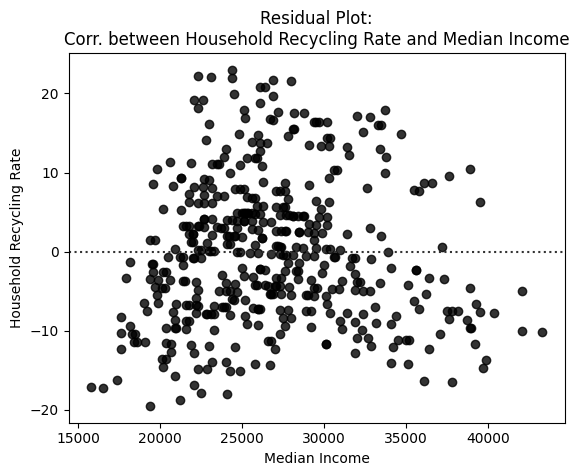

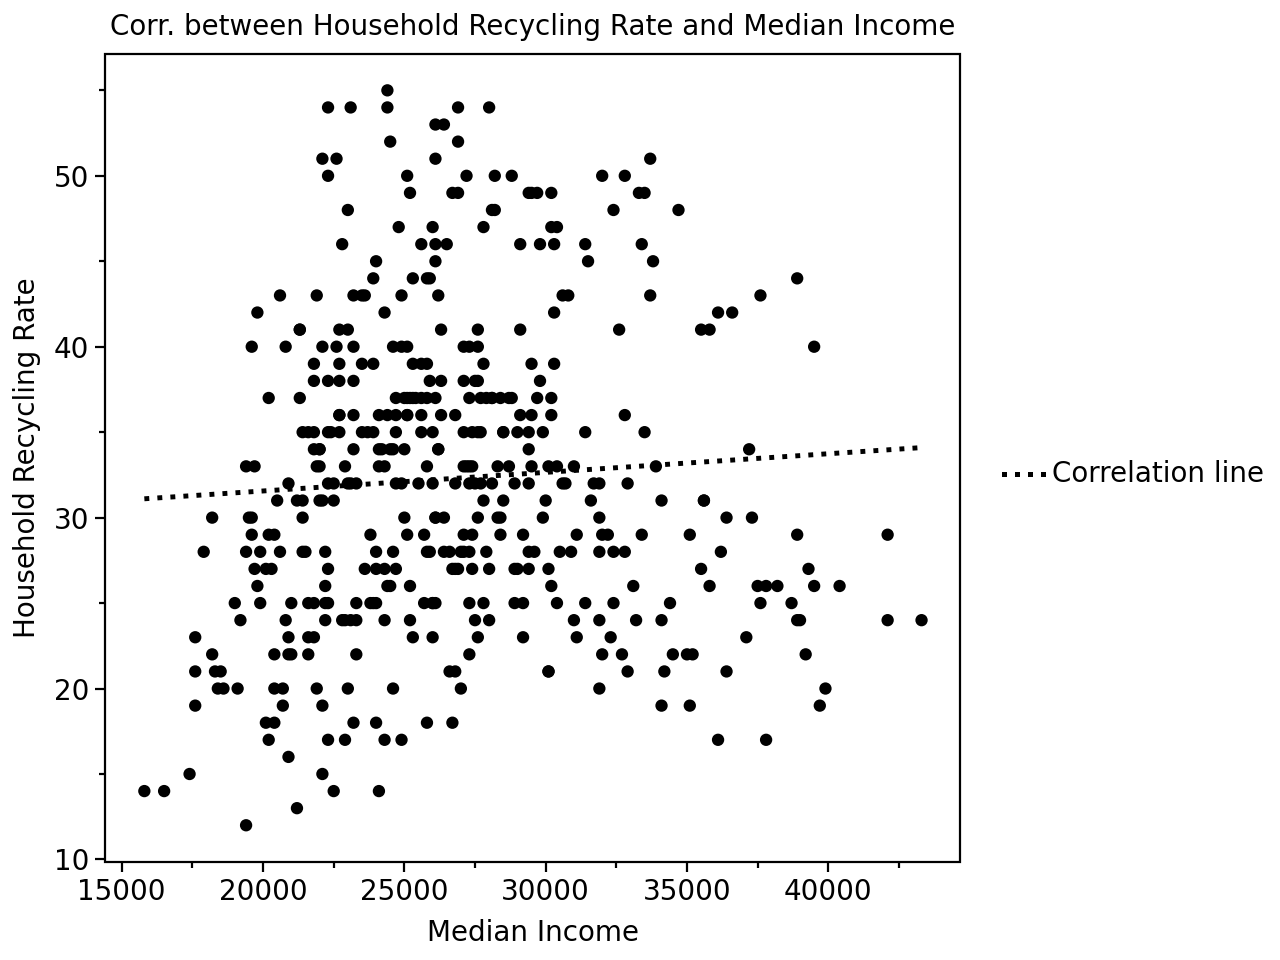

In [13]:
rec(final, "HHRR", "Median")

                            OLS Regression Results                            
Dep. Variable:                   HHRR   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     11.03
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           0.000968
Time:                        14:35:26   Log-Likelihood:                -1621.5
No. Observations:                 448   AIC:                             3247.
Df Residuals:                     446   BIC:                             3255.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.7376      0.848     40.947      0.0

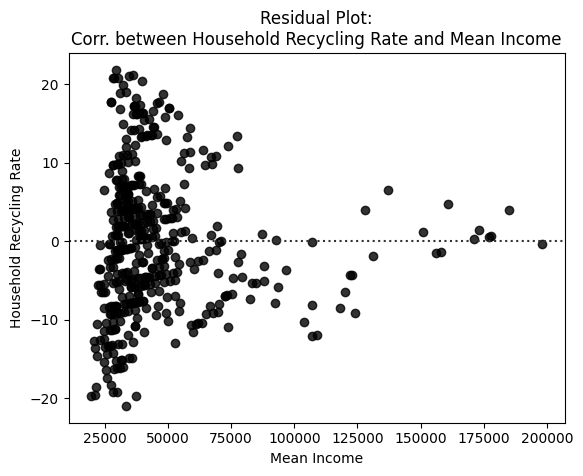

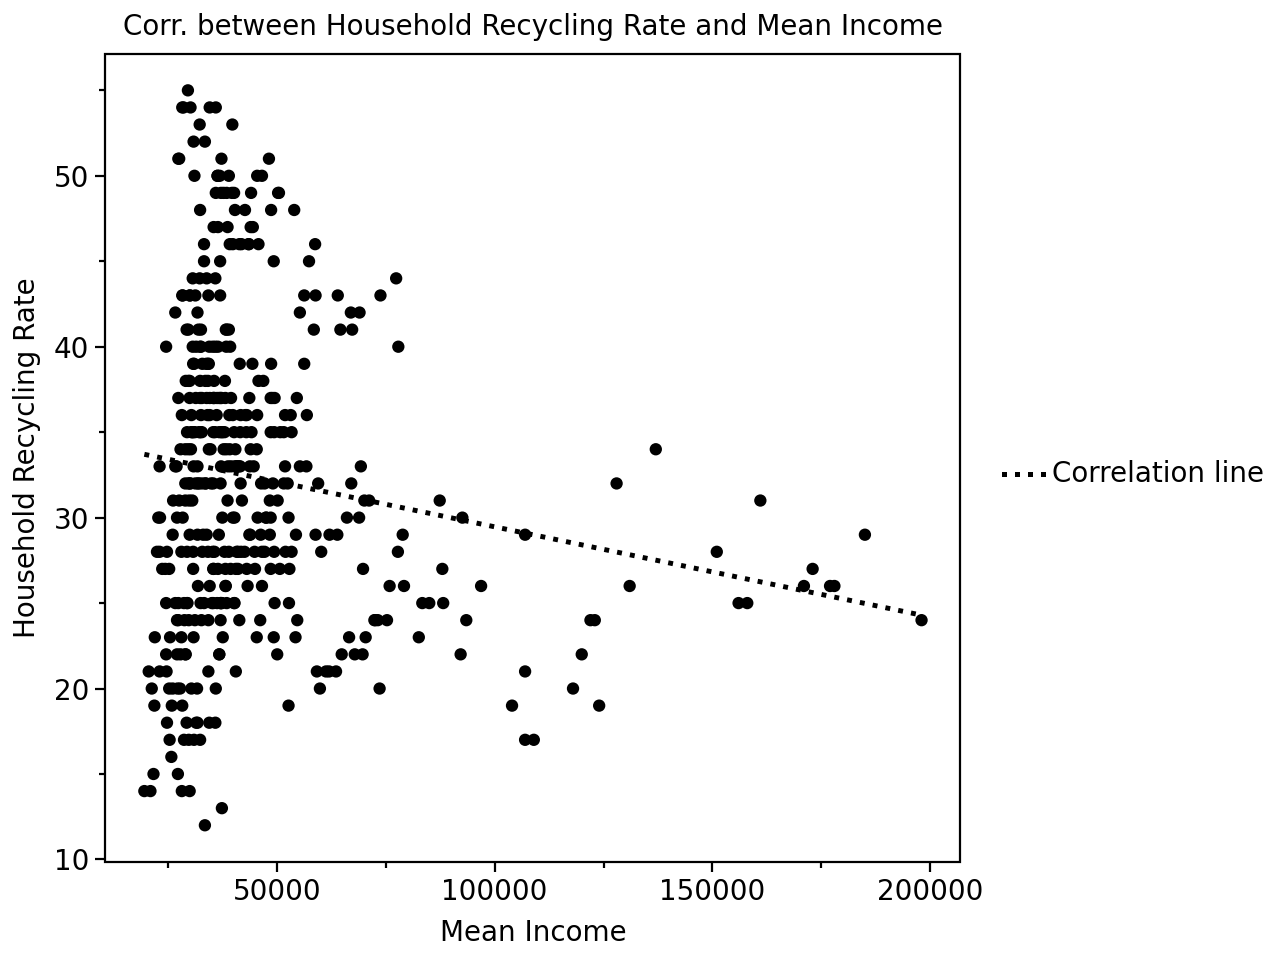

In [14]:
rec(final, "HHRR", "Mean")

                            OLS Regression Results                            
Dep. Variable:                   HHRR   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     288.6
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.81e-50
Time:                        14:35:27   Log-Likelihood:                -1515.1
No. Observations:                 448   AIC:                             3034.
Df Residuals:                     446   BIC:                             3042.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.2693      1.058     14.434      0.0

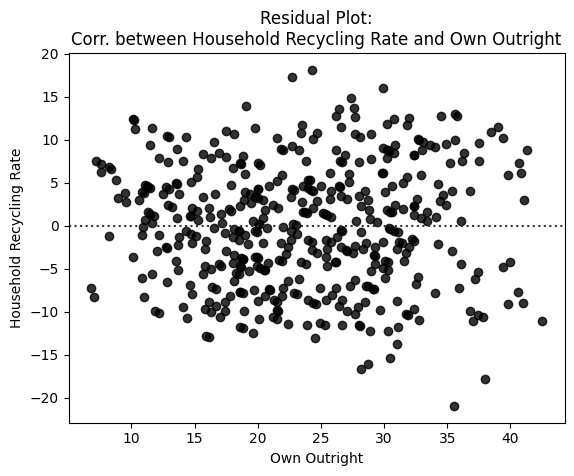

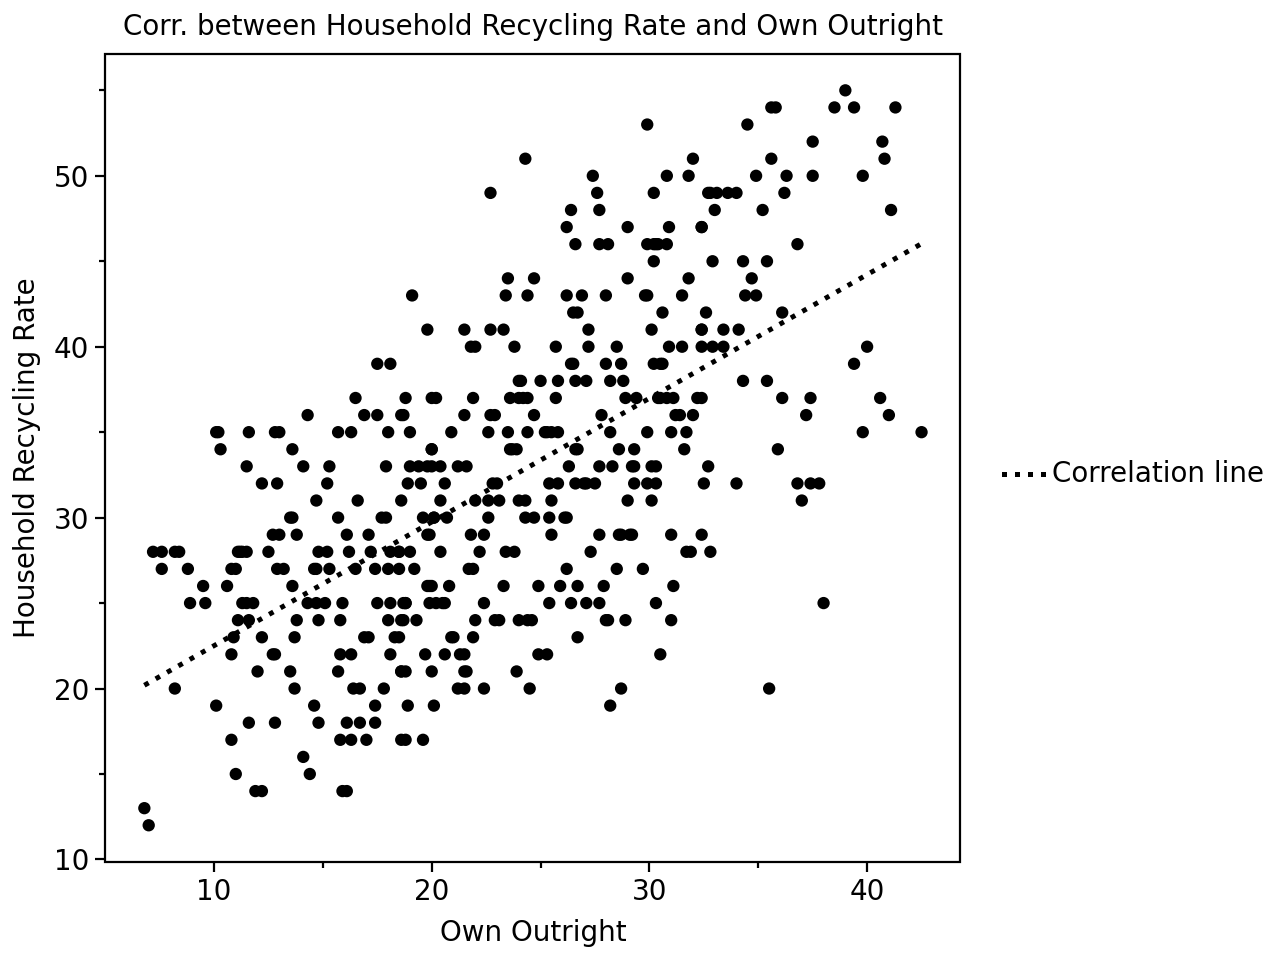

In [15]:
rec(final, "HHRR", "Own")

                            OLS Regression Results                            
Dep. Variable:                    Own   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.071
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.301
Time:                        14:35:27   Log-Likelihood:                -1561.9
No. Observations:                 448   AIC:                             3128.
Df Residuals:                     446   BIC:                             3136.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.3082      0.835     29.101      0.0

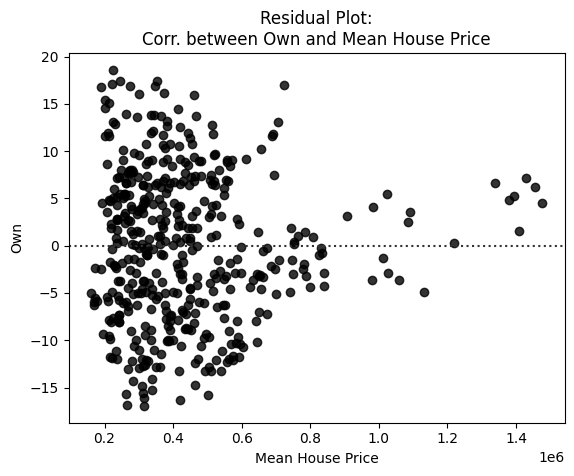

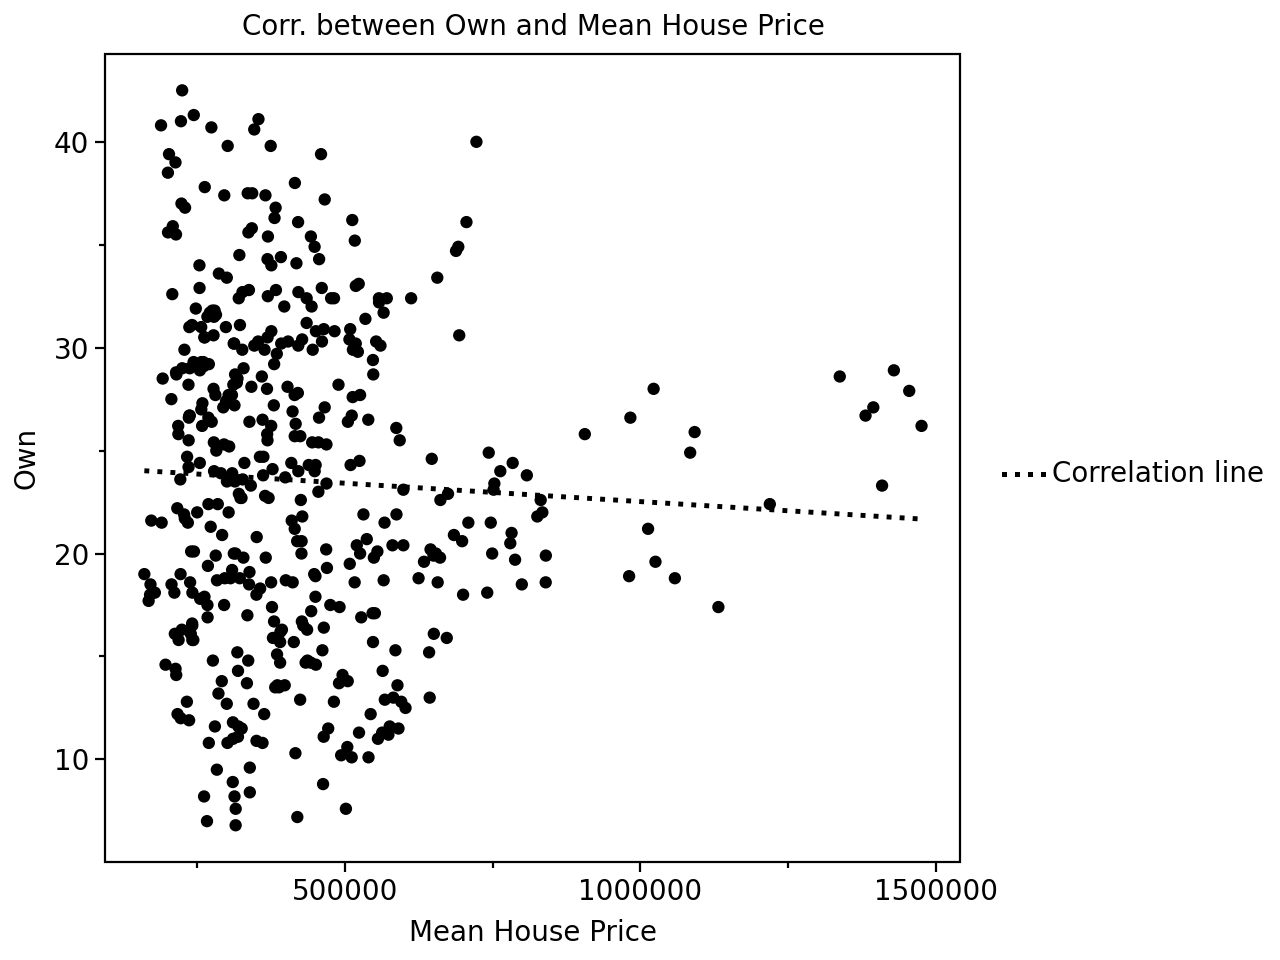

In [16]:
rec(final, "Own", "Price")